# Import Library

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Membaca Gambar

In [47]:
img = cv2.imread('nama.jpg')
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Konversi BGR ke RGB

In [4]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# EKSTRAKSI KANAL WARNA

In [31]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
gray = cv2.convertScaleAbs(gray, alpha=2.0, beta=-30)
gray_3 = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

red_mask = (R > 120) & (G < 120) & (B < 120)
green_mask = (G > 120) & (R < 120) & (B < 120)
blue_mask = (B > 120) & (R < 120) & (G < 120)

red_img = gray_3.copy()
green_img = gray_3.copy()
blue_img = gray_3.copy()

blue_img[blue_mask] = [220, 220, 220]
red_img[red_mask] = [220, 220, 220]
green_img[green_mask] = [220, 220, 220]

# MENAMPILKAN HASIL EKSTRAKSI WARNA

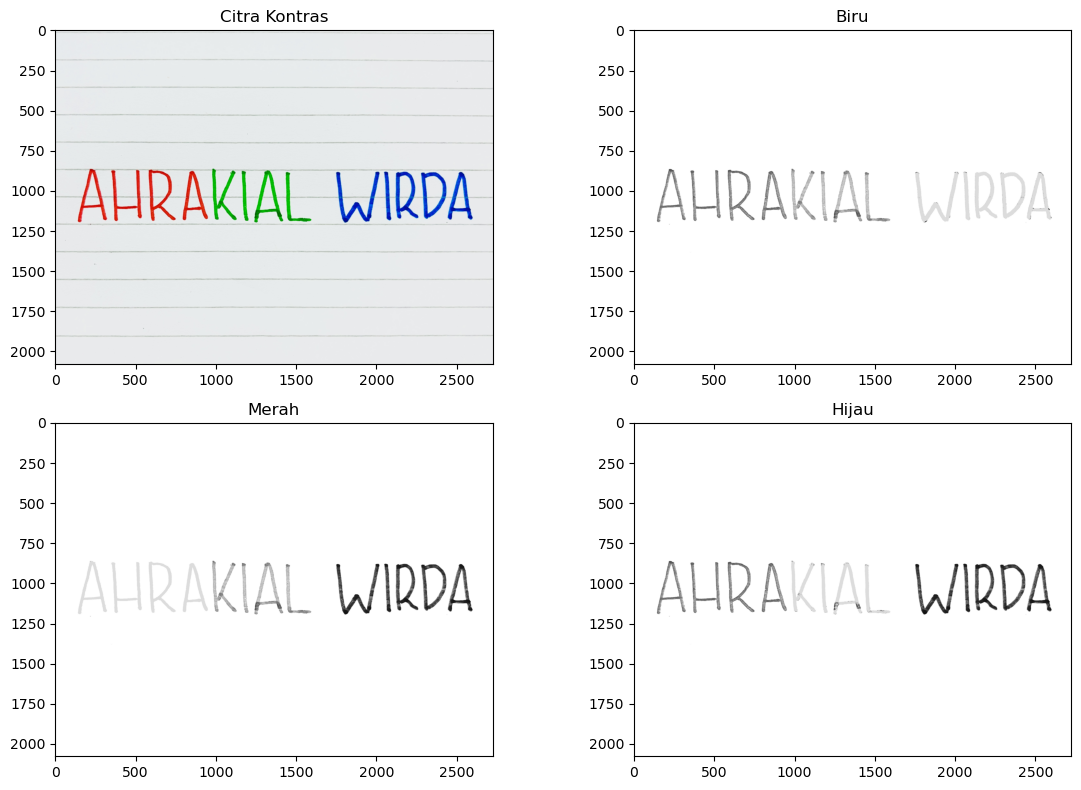

In [48]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img_rgb)
plt.title('Citra Kontras')
plt.axis('on')

plt.subplot(2,2,2)
plt.imshow(blue_img)
plt.title('Biru')
plt.axis('on')

plt.subplot(2,2,3)
plt.imshow(red_img)
plt.title('Merah')
plt.axis('on')

plt.subplot(2,2,4)
plt.imshow(green_img)
plt.title('Hijau')
plt.axis('on')

plt.tight_layout()
plt.show()

# AMBANG BATAS (THRESHOLD)

# Convert ke HSV

In [33]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Ekstraksi Merah

In [34]:
lower_red1 = np.array([0,100,100])
upper_red1 = np.array([10,255,255])

lower_red2 = np.array([160,100,100])
upper_red2 = np.array([180,255,255])

mask_red1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask_red2 = cv2.inRange(hsv, lower_red2, upper_red2)

mask_red = mask_red1 + mask_red2

# Ekstraksi Hijau

In [35]:
lower_green = np.array([40,50,50])
upper_green = np.array([80,255,255])

mask_green = cv2.inRange(hsv, lower_green, upper_green)

# Ekstraksi Biru

In [36]:
lower_blue = np.array([100,50,50])
upper_blue = np.array([140,255,255])

mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

# Ekstraksi Merah dan Biru

In [37]:
mask_red_blue = mask_red + mask_blue

# Ekstraksi Semua Warna

In [42]:
mask_all = mask_red + mask_green + mask_blue

# Menampilkan Hasil

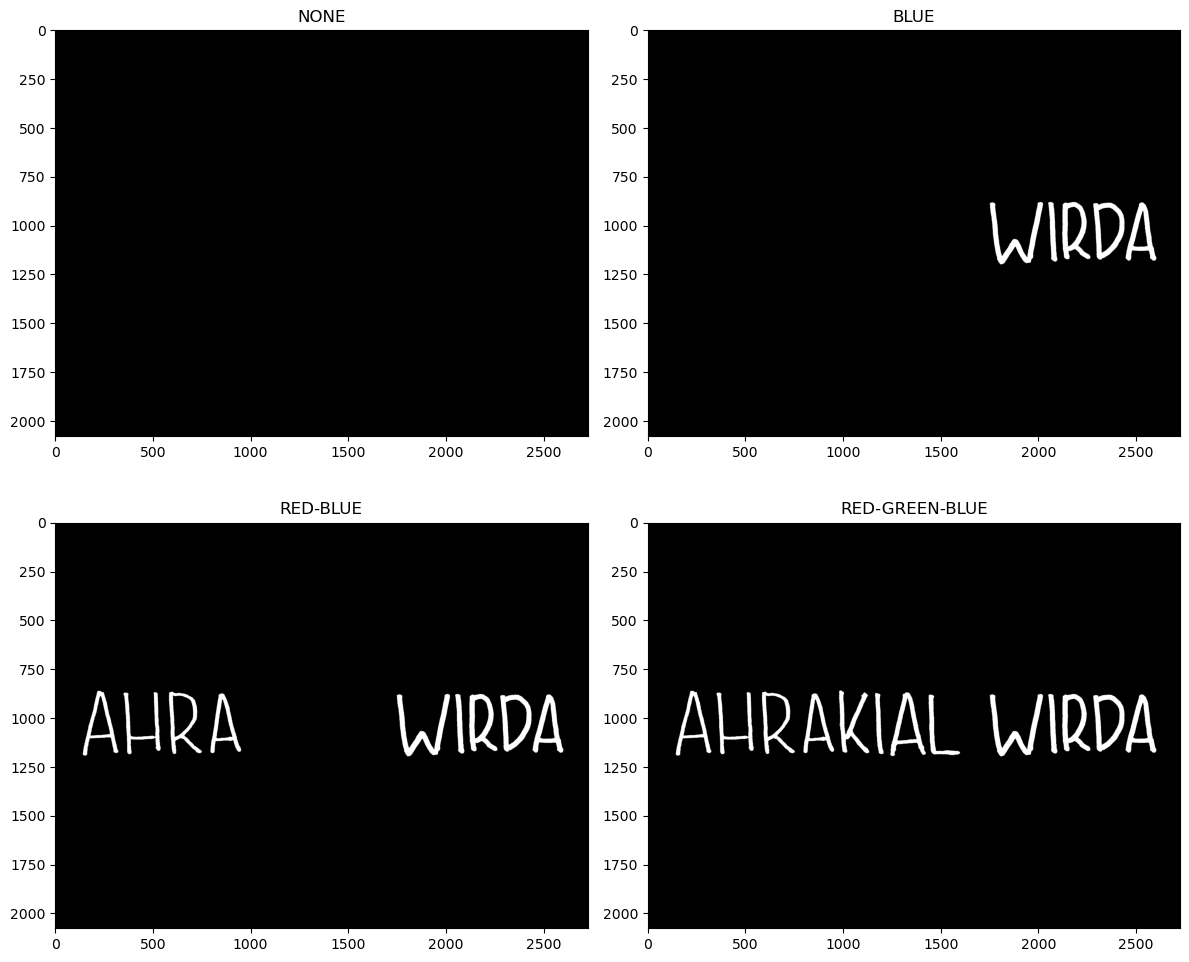

In [43]:
fig, axs = plt.subplots(2,2, figsize=(12,10))

# NONE
axs[0,0].imshow(np.zeros_like(mask_blue), cmap='gray')
axs[0,0].set_title("NONE")

# BLUE
axs[0,1].imshow(mask_blue, cmap='gray')
axs[0,1].set_title("BLUE")

# RED-BLUE
axs[1,0].imshow(mask_red_blue, cmap='gray')
axs[1,0].set_title("RED-BLUE")

# RED-GREEN-BLUE
axs[1,1].imshow(mask_all, cmap='gray')
axs[1,1].set_title("RED-GREEN-BLUE")

plt.tight_layout()
plt.show()

# HISTOGRAM

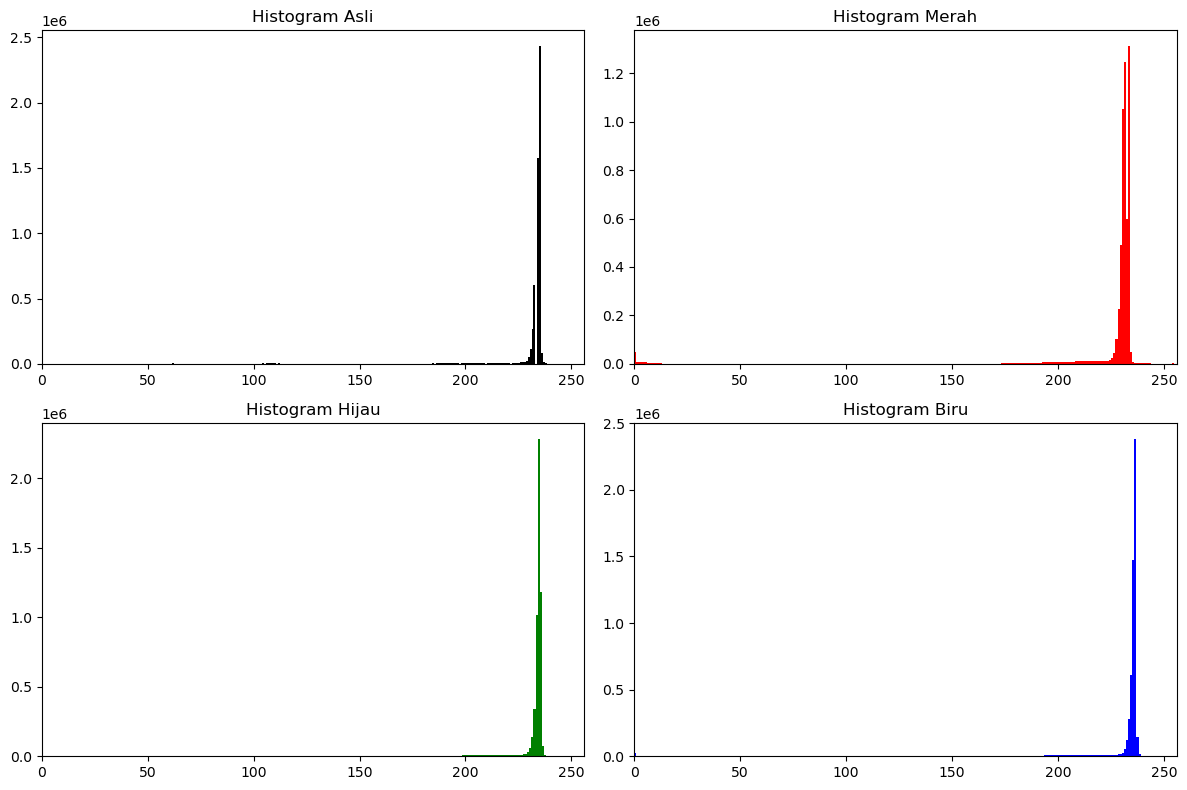

In [66]:
plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
plt.hist(gray_asli.ravel(), bins=256, color='black')
plt.title('Histogram Asli')
plt.xlim([0,256])

# Histogram Merah
plt.subplot(2, 2, 2)
plt.hist(R.ravel(), bins=256, color='red')
plt.title('Histogram Merah')
plt.xlim([0, 256])

# Histogram Hijau
plt.subplot(2, 2, 3)
plt.hist(G.ravel(), bins=256, color='green')
plt.title('Histogram Hijau')
plt.xlim([0, 256])

# Histogram Biru
plt.subplot(2, 2, 4)
plt.hist(B.ravel(), bins=256, color='blue')
plt.title('Histogram Biru')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()